# CNN Classification: Predict Cortical Layer from Functional Time Series

Upgrade over the naive MLP baseline using a **1D convolutional neural network**.

Key improvements over `naive classification approach.ipynb`:
- **Neuron-level train/test split**: a neuron's trials all go to either train or test, never both — more realistic evaluation
- **1D CNN** that treats the fluorescence trace as a temporal signal and learns local convolutional features, instead of treating all timepoints as independent flat features
- **Two architectures compared**: shallow CNN and a deeper residual CNN
- Same class-weighted cross-entropy and early stopping as before

Reference results from naive baseline (balanced accuracy):
- Dummy: 0.250 | Logistic Regression: 0.273 | KNN: 0.260 | Random Forest: 0.256 | MLP: ~0.25

## 1. Load structural metadata and functional file

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

import microns_datacleaner as mic
import microns_datacleaner.filters as fl

warnings.filterwarnings('ignore')
np.random.seed(42)

# Walk up from CWD until we find microns.h5 — robust regardless of which
# directory Jupyter was launched from.
def _find_root():
    p = Path.cwd()
    while p != p.parent:
        if (p / 'microns.h5').exists():
            return p
        p = p.parent
    raise RuntimeError('Cannot find workspace root: no microns.h5 found while walking up from ' + str(Path.cwd()))

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f'Workspace root: {ROOT}')

Workspace root: c:\Users\tomma\Desktop\NEUROSCIENCE


In [2]:
cleaner = mic.MicronsDataCleaner(datadir=os.path.relpath(str(ROOT / 'data')), version=1718, download_policy='minimum')
units_match, _ = cleaner.process_nucleus_data(functional_data='match')

matched = fl.filter_neurons(
    units_match,
    tuning='matched',
    cell_type='excitatory_neuron',
    brain_area='V1'
).copy()

unit_id_col = None
for col_name in ['functional_unit_id', 'unit_id', 'index', 'neuron_idx', 'neuron_id']:
    if col_name in matched.columns:
        unit_id_col = col_name
        break

if unit_id_col is None:
    raise ValueError(f'No usable neuron index column. Available: {list(matched.columns)}')

print(f'Matched neurons: {len(matched)}')
print(f'Unit id column: {unit_id_col}')
print(matched['layer'].value_counts(dropna=False).sort_index().to_string())

Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 89351.81it/s]


Matched neurons: 13044
Unit id column: functional_unit_id
layer
L1        16
L2/3    6340
L4      3941
L5      2269
L6       478


In [3]:
from reader import MicronsReader

# microns.h5 at the workspace root is the primary file (it has unit_ids and integer trial keys)
functional_path = ROOT / 'microns.h5'
if not functional_path.exists():
    alt = ROOT / 'data' / 'functional' / 'microns_functional.h5'
    if alt.exists():
        functional_path = alt
    else:
        raise FileNotFoundError(f'No functional H5 found. Tried: {ROOT / "microns.h5"} and {alt}')

print(f'Using functional file: {functional_path}')
funcreader  = MicronsReader(str(functional_path))
session_keys = list(funcreader.f['sessions'].keys())

scan_rows = []
for k in session_keys:
    parts = k.split('_')
    if len(parts) == 2:
        try:
            scan_rows.append((int(parts[0]), int(parts[1]), k))
        except ValueError:
            pass

scan_df = pd.DataFrame(scan_rows, columns=['session', 'scan_idx', 'key']).sort_values(['session', 'scan_idx'])
print(f'Session/scan keys available: {len(scan_df)}')

Using functional file: c:\Users\tomma\Desktop\NEUROSCIENCE\microns.h5
Session/scan keys available: 14


## 2. Collect trial traces (all session/scan pairs)

In [4]:
MAX_TRIALS_PER_SCAN = 8
MIN_TRACE_LEN       = 60
MAX_FEATURE_LEN     = 300
EXCLUDE_LAYERS      = {'L1'}

records = []

matched_scans = matched[['session', 'scan_idx']].dropna().drop_duplicates().copy()
matched_scans['session']  = matched_scans['session'].astype(int)
matched_scans['scan_idx'] = matched_scans['scan_idx'].astype(int)

scan_candidates = scan_df.merge(matched_scans, on=['session', 'scan_idx'], how='inner')
scan_candidates = scan_candidates.sort_values(['session', 'scan_idx']).reset_index(drop=True)
print(f'Candidate session/scan pairs: {len(scan_candidates)}')

for _, row in scan_candidates.iterrows():
    session  = int(row['session'])
    scan_idx = int(row['scan_idx'])
    key      = row['key']

    session_neurons = matched[
        (matched['session'] == session) & (matched['scan_idx'] == scan_idx)
    ].copy()
    session_neurons = session_neurons.dropna(subset=[unit_id_col, 'layer'])
    session_neurons['layer'] = session_neurons['layer'].astype(str)
    session_neurons = session_neurons[~session_neurons['layer'].isin(EXCLUDE_LAYERS)]
    if session_neurons.empty:
        continue

    hashes = funcreader.get_hashes_by_session(key)
    if len(hashes) == 0:
        continue

    unit_ids       = funcreader.f[f'sessions/{key}/meta/unit_ids'][:]
    unit_id_to_row = {int(u): idx for idx, u in enumerate(unit_ids)}
    n_trials       = min(len(hashes), MAX_TRIALS_PER_SCAN)

    for t in range(n_trials):
        try:
            td = funcreader.get_trial(key, t)
        except (ValueError, KeyError):
            continue
        if td is None:
            continue
        responses = td['responses']

        for _, nr in session_neurons.iterrows():
            layer   = str(nr['layer'])
            fuid    = int(nr[unit_id_col])
            row_idx = unit_id_to_row.get(fuid)
            if row_idx is None or row_idx >= responses.shape[0]:
                continue

            trace = np.asarray(responses[row_idx, :], dtype=np.float32).ravel()
            trace = trace[np.isfinite(trace)]
            if trace.size < MIN_TRACE_LEN:
                continue

            records.append({
                'layer':     layer,
                'trace':     trace,
                'unit_id':   fuid,
                'session':   session,
                'scan_idx':  scan_idx,
                'trial_idx': t,
            })

print(f'Total samples: {len(records)}')
print(pd.Series([r["layer"] for r in records]).value_counts().sort_index().to_string())

target_len = min(MAX_FEATURE_LEN, min(len(r['trace']) for r in records))
print(f'Trace length used: {target_len} timepoints')

Candidate session/scan pairs: 14
Total samples: 99384
L2/3    48872
L4      29984
L5      16936
L6       3592
Trace length used: 75 timepoints


## 3. Neuron-level train/test split

All trials from a given neuron are assigned exclusively to train **or** test.  
This prevents the model from "memorising" a neuron it has already seen and gives a more realistic estimate of generalisation to unseen neurons.

In [5]:
df = pd.DataFrame([
    {'unit_id': r['unit_id'], 'layer': r['layer']} for r in records
])

# One row per neuron: take the most common layer label (should be constant per neuron)
neuron_df = (
    df.groupby('unit_id')['layer']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={'layer': 'layer'})
)

# Drop very rare layers
layer_counts = neuron_df['layer'].value_counts()
keep_layers  = layer_counts[layer_counts >= 20].index.tolist()
neuron_df    = neuron_df[neuron_df['layer'].isin(keep_layers)]
print(f'Neurons per layer (after rare-class filter):')
print(neuron_df['layer'].value_counts().sort_index().to_string())

# Stratified 75/25 split on neuron identities
train_neurons, test_neurons = train_test_split(
    neuron_df['unit_id'].values,
    test_size=0.25,
    random_state=42,
    stratify=neuron_df['layer'].values,
)
train_set = set(train_neurons)
test_set  = set(test_neurons)
print(f'\nTrain neurons: {len(train_set)} | Test neurons: {len(test_set)}')

# Build feature matrices, keeping only neurons assigned to each split
enc = LabelEncoder()
enc.fit(neuron_df['layer'])

def build_split(unit_ids_set):
    X, y, uids = [], [], []
    for r in records:
        if r['unit_id'] not in unit_ids_set:
            continue
        if r['layer'] not in keep_layers:
            continue
        trace = r['trace'][:target_len]
        trace = (trace - trace.mean()) / (trace.std() + 1e-8)
        X.append(trace)
        y.append(r['layer'])
        uids.append(r['unit_id'])
    return np.asarray(X, dtype=np.float32), enc.transform(y), np.array(uids)

X_train, y_train, uids_train = build_split(train_set)
X_test,  y_test,  uids_test  = build_split(test_set)

print(f'\nTrain samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}')
print('Train class distribution:')
print(pd.Series(enc.inverse_transform(y_train)).value_counts().sort_index().to_string())
print('Test class distribution:')
print(pd.Series(enc.inverse_transform(y_test)).value_counts().sort_index().to_string())

Neurons per layer (after rare-class filter):
layer
L2/3    2870
L4      1923
L5      1430
L6       325

Train neurons: 4911 | Test neurons: 1637

Train samples: 73912 | Test samples: 25472
Train class distribution:
L2/3    36176
L4      22216
L5      12832
L6       2688
Test class distribution:
L2/3    12696
L4       7768
L5       4104
L6        904


## 4. PyTorch setup and DataLoaders

Input shape for 1D CNN: `(batch, 1, T)` — single channel, T timepoints.

In [6]:
import importlib, subprocess, sys

if importlib.util.find_spec('torch') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', 'torch',
                           '--index-url', 'https://download.pytorch.org/whl/cpu'])

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {DEVICE}')

# ── Class weights ─────────────────────────────────────────────────────────────
n_classes    = len(enc.classes_)
class_counts = np.bincount(y_train, minlength=n_classes).astype(np.float32)
class_weights = torch.tensor(1.0 / (class_counts + 1e-8)).to(DEVICE)
class_weights /= class_weights.sum()

BATCH_SIZE = 256

# CNN expects shape (B, 1, T)
def make_loader(X, y, shuffle):
    Xt = torch.tensor(X[:, None, :], dtype=torch.float32)   # add channel dim
    yt = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=False)

train_loader = make_loader(X_train, y_train, shuffle=True)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

PyTorch 2.11.0+cpu | device: cpu
Train batches: 289 | Test batches: 100


## 5. Model definitions

### Architecture A — Shallow CNN
Three conv blocks (Conv → BN → ReLU → MaxPool) followed by a two-layer MLP head.  
Kernel size 7 captures ~0.35 s of activity at 20 Hz imaging rate.

### Architecture B — Residual CNN
Same backbone but with skip connections (residual blocks) so gradients flow more easily through deeper stacks.  
Useful here because the signal-to-noise ratio is very low and overfitting risk is high.

In [8]:
class ShallowCNN(nn.Module):
    """
    3 convolutional blocks (Conv1d → BN → ReLU → MaxPool) + 2-layer MLP head.
    Channels: 1 → 32 → 64 → 128.  MaxPool(2) after each block.
    """
    def __init__(self, seq_len: int, n_classes: int, dropout: float = 0.4):
        super().__init__()
        self.conv = nn.Sequential(
            # block 1
            nn.Conv1d(1,  32, kernel_size=7, padding=3), nn.BatchNorm1d(32),  nn.ReLU(True), nn.MaxPool1d(2),
            # block 2
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64),  nn.ReLU(True), nn.MaxPool1d(2),
            # block 3
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128), nn.ReLU(True), nn.MaxPool1d(2),
        )
        # Compute flattened size after convolutions
        flat = 128 * (seq_len // 8)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 128), nn.ReLU(True), nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):          # x: (B, 1, T)
        return self.head(self.conv(x))


class ResBlock1d(nn.Module):
    """1D residual block: two Conv layers with a skip connection."""
    def __init__(self, channels: int, kernel_size: int = 3):
        super().__init__()
        pad = kernel_size // 2
        self.net = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=pad, bias=False),
            nn.BatchNorm1d(channels), nn.ReLU(True),
            nn.Conv1d(channels, channels, kernel_size, padding=pad, bias=False),
            nn.BatchNorm1d(channels),
        )
        self.act = nn.ReLU(True)

    def forward(self, x):
        return self.act(self.net(x) + x)


class ResidualCNN(nn.Module):
    """
    Stem conv (1→64) + 3 residual stages, each followed by stride-2 downsampling.
    Stages: 64ch → 128ch → 256ch.  Global average pooling → FC head.
    """
    def __init__(self, seq_len: int, n_classes: int, dropout: float = 0.4):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(True),
        )
        self.stage1 = nn.Sequential(
            ResBlock1d(64),
            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(128), nn.ReLU(True),
        )
        self.stage2 = nn.Sequential(
            ResBlock1d(128),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(256), nn.ReLU(True),
        )
        self.stage3 = nn.Sequential(
            ResBlock1d(256),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)   # → (B, 256, 1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(True),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x)
        return self.head(x)


shallow_cnn  = ShallowCNN(target_len,  n_classes).to(DEVICE)
residual_cnn = ResidualCNN(target_len, n_classes).to(DEVICE)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f'ShallowCNN  params: {count_params(shallow_cnn):,}')
print(f'ResidualCNN params: {count_params(residual_cnn):,}')

ShallowCNN  params: 183,812
ResidualCNN params: 675,524


## 6. Training loop (shared for both architectures)

In [9]:
def train_model(model, train_loader, test_loader, *,
                lr=3e-4, weight_decay=1e-4,
                max_epochs=150, patience=15,
                label='model'):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=max_epochs)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state    = None
    patience_cnt  = 0

    for epoch in range(1, max_epochs + 1):
        # train
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimiser.step()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # validate
        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                val_loss += criterion(logits, yb).item() * xb.size(0)
                correct  += (logits.argmax(1) == yb).sum().item()
        val_loss /= len(test_loader.dataset)
        val_acc   = correct / len(test_loader.dataset)

        scheduler.step()
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt  = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'[{label}] Early stop at epoch {epoch}')
                break

        if epoch % 10 == 0 or epoch == 1:
            print(f'[{label}] Epoch {epoch:3d} | train={train_loss:.4f}  val={val_loss:.4f}  acc={val_acc:.3f}')

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    print(f'[{label}] Restored best checkpoint (val_loss={best_val_loss:.4f})')
    return history


def evaluate(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(preds)

## 7. Train ShallowCNN

In [10]:
shallow_cnn = ShallowCNN(target_len, n_classes).to(DEVICE)
history_shallow = train_model(shallow_cnn, train_loader, test_loader, label='ShallowCNN')

[ShallowCNN] Epoch   1 | train=1.3715  val=1.3146  acc=0.269
[ShallowCNN] Epoch  10 | train=1.2615  val=1.2742  acc=0.261
[ShallowCNN] Epoch  20 | train=1.1368  val=1.3259  acc=0.280
[ShallowCNN] Early stop at epoch 21
[ShallowCNN] Restored best checkpoint (val_loss=1.2603)


## 8. Train ResidualCNN

In [11]:
residual_cnn = ResidualCNN(target_len, n_classes).to(DEVICE)
history_res = train_model(residual_cnn, train_loader, test_loader, label='ResidualCNN')

[ResidualCNN] Epoch   1 | train=1.3456  val=1.2863  acc=0.171
[ResidualCNN] Epoch  10 | train=1.2841  val=1.2697  acc=0.213
[ResidualCNN] Epoch  20 | train=1.2214  val=1.2962  acc=0.243
[ResidualCNN] Early stop at epoch 23
[ResidualCNN] Restored best checkpoint (val_loss=1.2513)


## 9. Training curves

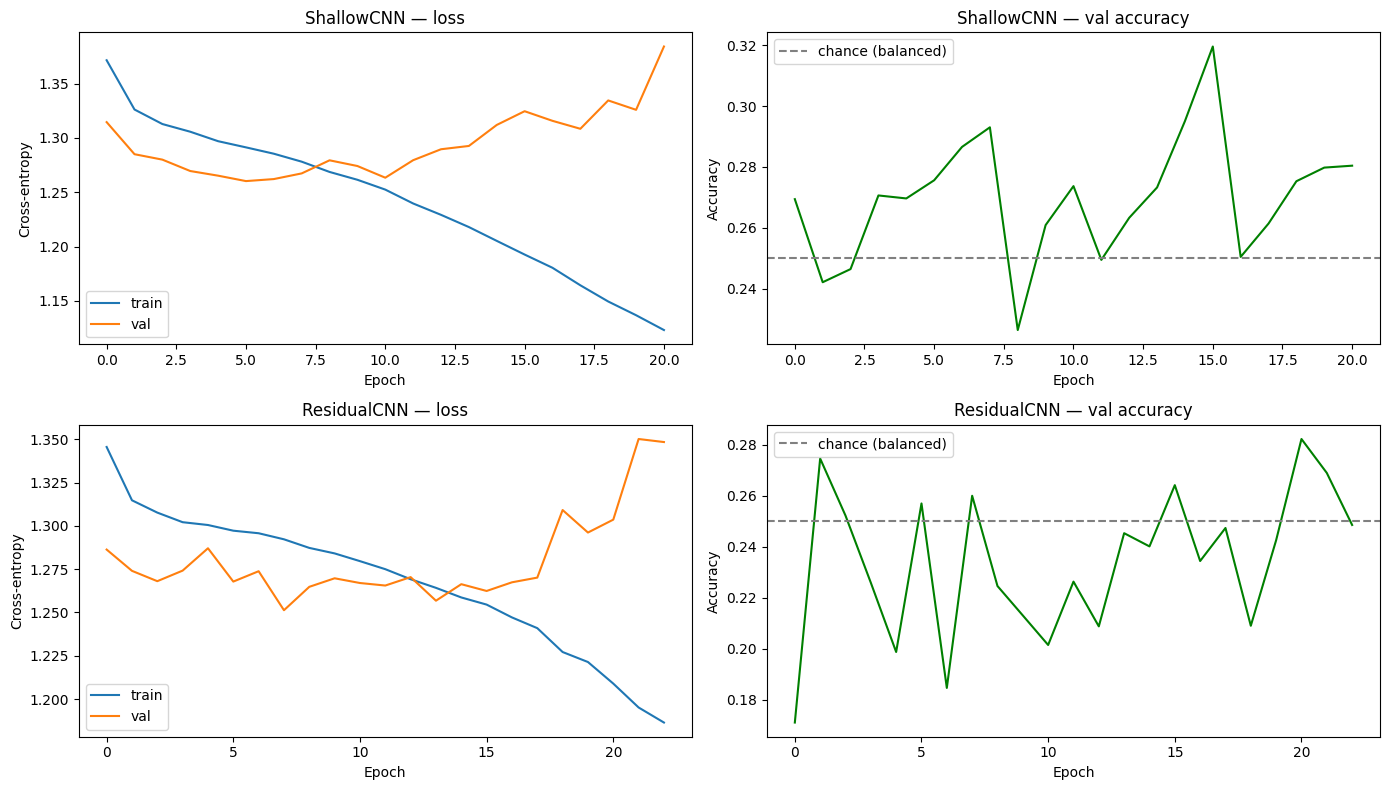

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, (hist, name) in enumerate([
    (history_shallow, 'ShallowCNN'),
    (history_res,     'ResidualCNN'),
]):
    ax_loss, ax_acc = axes[row]

    ax_loss.plot(hist['train_loss'], label='train')
    ax_loss.plot(hist['val_loss'],   label='val')
    ax_loss.set_title(f'{name} — loss')
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Cross-entropy')
    ax_loss.legend()

    ax_acc.plot(hist['val_acc'], color='green')
    ax_acc.axhline(0.25, color='grey', linestyle='--', label='chance (balanced)')
    ax_acc.set_title(f'{name} — val accuracy')
    ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()

plt.tight_layout()
plt.show()

## 10. Evaluation metrics and model comparison

In [13]:
results = []

for model, name in [(shallow_cnn, 'ShallowCNN'), (residual_cnn, 'ResidualCNN')]:
    y_pred = evaluate(model, test_loader)
    results.append({
        'model':             name,
        'accuracy':          accuracy_score(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'macro_f1':          f1_score(y_test, y_pred, average='macro'),
    })
    print(f'\n── {name} ──')
    print(classification_report(y_test, y_pred, target_names=enc.classes_))

# Naive baseline reference rows (from naive classification approach.ipynb)
naive_rows = [
    {'model': 'Dummy (ref)',              'accuracy': 0.4918, 'balanced_accuracy': 0.250, 'macro_f1': 0.165},
    {'model': 'LogisticRegression (ref)', 'accuracy': 0.2347, 'balanced_accuracy': 0.273, 'macro_f1': 0.215},
    {'model': 'RandomForest (ref)',       'accuracy': 0.4837, 'balanced_accuracy': 0.256, 'macro_f1': 0.200},
    {'model': 'MLP (ref)',                'accuracy': None,   'balanced_accuracy': None,  'macro_f1': None},
]

comparison = pd.DataFrame(results + naive_rows).sort_values('balanced_accuracy', ascending=False)
print('\n── Model comparison (sorted by balanced accuracy) ──')
display(comparison.reset_index(drop=True))


── ShallowCNN ──
              precision    recall  f1-score   support

        L2/3       0.59      0.21      0.31     12696
          L4       0.36      0.26      0.31      7768
          L5       0.23      0.46      0.31      4104
          L6       0.05      0.42      0.10       904

    accuracy                           0.28     25472
   macro avg       0.31      0.34      0.26     25472
weighted avg       0.45      0.28      0.30     25472


── ResidualCNN ──
              precision    recall  f1-score   support

        L2/3       0.60      0.18      0.28     12696
          L4       0.36      0.29      0.32      7768
          L5       0.23      0.41      0.29      4104
          L6       0.05      0.48      0.10       904

    accuracy                           0.26     25472
   macro avg       0.31      0.34      0.25     25472
weighted avg       0.45      0.26      0.29     25472


── Model comparison (sorted by balanced accuracy) ──


,model,accuracy,balanced_accuracy,macro_f1
0,ShallowCNN,0.275636,0.340100,0.255195
1,ResidualCNN,0.259932,0.339524,0.245973
2,LogisticRegression (ref),0.234700,0.273000,0.215000
3,RandomForest (ref),0.483700,0.256000,0.200000
4,Dummy (ref),0.491800,0.250000,0.165000
5,MLP (ref),NaN,NaN,NaN


## 11. Confusion matrices

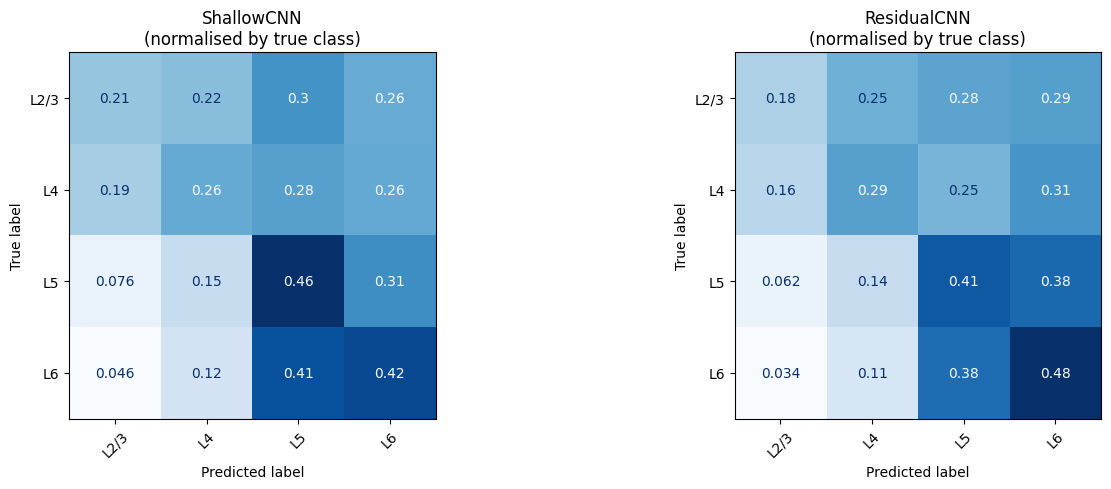

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model, name) in zip(axes, [(shallow_cnn, 'ShallowCNN'), (residual_cnn, 'ResidualCNN')]):
    y_pred = evaluate(model, test_loader)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=enc.classes_,
        xticks_rotation=45,
        cmap='Blues',
        ax=ax,
        normalize='true',
        colorbar=False,
    )
    ax.set_title(f'{name}\n(normalised by true class)')

plt.tight_layout()
plt.show()

## 12. Per-neuron accuracy (aggregated predictions)

Each test neuron contributes multiple trial predictions.  
Majority-vote across a neuron's trials may boost accuracy because noise averages out.

In [15]:
from scipy.stats import mode as scipy_mode

def per_neuron_majority_vote(model, X, y, uids):
    """Majority-vote predictions across trials for each neuron."""
    loader = make_loader(X, y, shuffle=False)
    preds  = evaluate(model, loader)

    neuron_preds = {}
    neuron_true  = {}
    for uid, pred, true in zip(uids, preds, y):
        neuron_preds.setdefault(uid, []).append(pred)
        neuron_true[uid] = true

    voted_preds = []
    voted_true  = []
    for uid in neuron_preds:
        majority = scipy_mode(neuron_preds[uid], keepdims=False).mode
        voted_preds.append(majority)
        voted_true.append(neuron_true[uid])

    voted_preds = np.array(voted_preds)
    voted_true  = np.array(voted_true)
    return voted_true, voted_preds


print('Per-neuron majority-vote results:')
for model, name in [(shallow_cnn, 'ShallowCNN'), (residual_cnn, 'ResidualCNN')]:
    vt, vp = per_neuron_majority_vote(model, X_test, y_test, uids_test)
    print(f'\n{name}:')
    print(f'  Neurons evaluated: {len(vt)}')
    print(f'  Accuracy:          {accuracy_score(vt, vp):.3f}')
    print(f'  Balanced accuracy: {balanced_accuracy_score(vt, vp):.3f}')
    print(f'  Macro F1:          {f1_score(vt, vp, average="macro"):.3f}')
    print(classification_report(vt, vp, target_names=enc.classes_))

Per-neuron majority-vote results:

ShallowCNN:
  Neurons evaluated: 1637
  Accuracy:          0.290
  Balanced accuracy: 0.357
  Macro F1:          0.253
              precision    recall  f1-score   support

        L2/3       0.74      0.21      0.32       837
          L4       0.32      0.21      0.25       460
          L5       0.27      0.63      0.38       306
          L6       0.03      0.38      0.06        34

    accuracy                           0.29      1637
   macro avg       0.34      0.36      0.25      1637
weighted avg       0.52      0.29      0.31      1637


ResidualCNN:
  Neurons evaluated: 1637
  Accuracy:          0.257
  Balanced accuracy: 0.387
  Macro F1:          0.240
              precision    recall  f1-score   support

        L2/3       0.74      0.15      0.25       837
          L4       0.33      0.24      0.28       460
          L5       0.27      0.55      0.36       306
          L6       0.04      0.62      0.08        34

    accuracy      

## 13. Learned filter visualisation (ShallowCNN)

Plotting the first-layer convolutional filters lets us see what temporal patterns the CNN has learned to detect.  
Each filter is a 1×7 kernel that responds maximally to a specific local waveform shape.

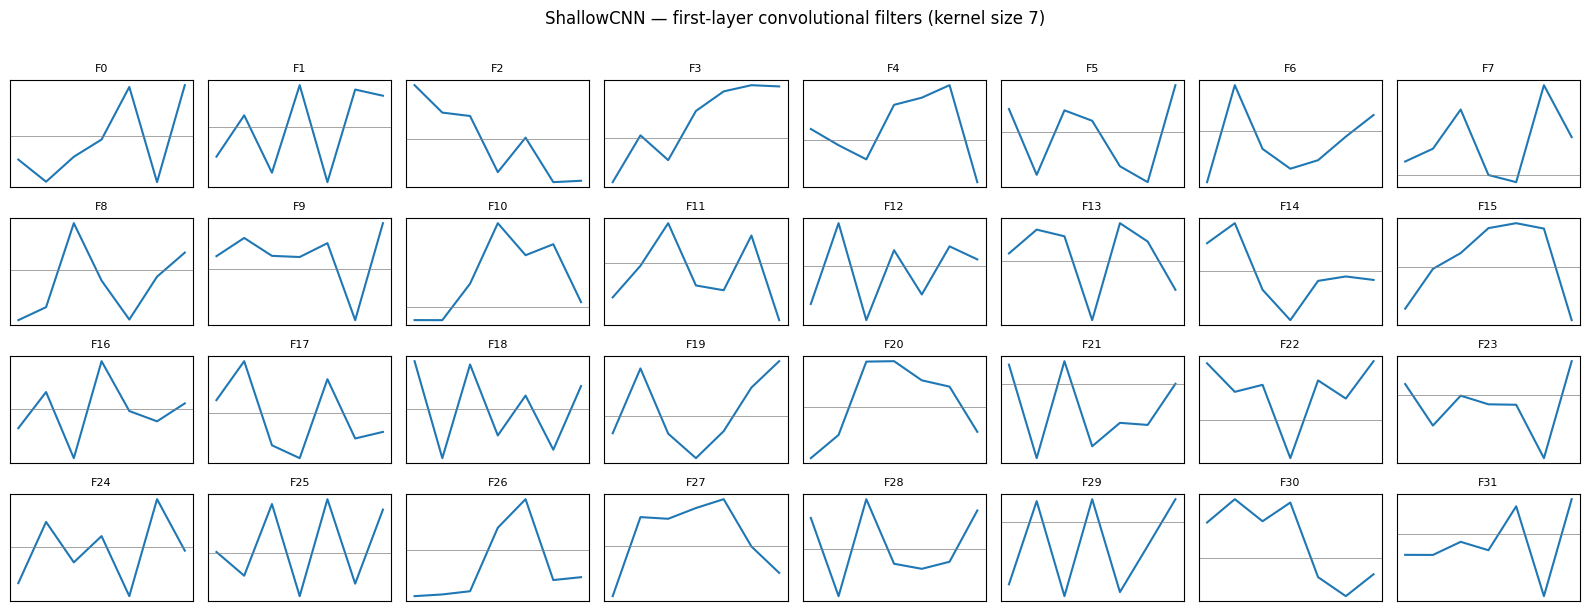

In [16]:
# Extract and plot the 32 first-layer filters of ShallowCNN
first_conv = shallow_cnn.conv[0]   # nn.Conv1d(1, 32, kernel_size=7)
filters = first_conv.weight.detach().cpu().numpy()  # shape: (32, 1, 7)

fig, axes = plt.subplots(4, 8, figsize=(16, 6))
for i, ax in enumerate(axes.ravel()):
    if i < filters.shape[0]:
        ax.plot(filters[i, 0], linewidth=1.5)
        ax.axhline(0, color='grey', linewidth=0.5)
        ax.set_title(f'F{i}', fontsize=8)
    ax.axis('off') if i >= filters.shape[0] else None
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('ShallowCNN — first-layer convolutional filters (kernel size 7)', y=1.01)
plt.tight_layout()
plt.show()

## 14. Interpretation and next steps

### What to look for in the results
- **Balanced accuracy > 0.27**: beats the best naive baseline (logistic regression on raw traces, *same-neuron* split)
- **Confusion matrix**: check whether L4/L5 confusion dominates — these are the intermediate layers most likely to be misclassified  
- **Per-neuron vs per-trial**: majority vote over trials usually improves accuracy by 5–10 pp because it cancels single-trial noise

### Likely outcomes given EDA findings
The EDA showed near-zero between-layer discriminability in raw time series.  
The CNN will likely still converge to low balanced accuracy (~0.25–0.35) because:
- Within-layer variability >> between-layer differences
- 75 timepoints at single-trial resolution carry very little systematic signal
- The neuron-level split is harder than the naive split — the model cannot memorise neuron-specific baselines

### Suggested next steps (in order of expected payoff)
1. **Trial-averaged features**: average all trials per neuron per stimulus type before classifying — dramatically reduces noise
2. **Stimulus-conditioned training**: train separate models per stimulus type (Clip / Monet2 / Trippy) 
3. **Frequency-domain input**: add FFT magnitudes or wavelet coefficients as additional channels alongside the raw trace
4. **Behavioural covariates as auxiliary input**: concatenate treadmill speed / pupil size as extra features — removes gain modulation
5. **cc_abs quality filter**: restrict to neurons with cc_abs > 0.3 to focus on reliably driven units